In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [9]:
df.shape

(891, 12)

In [11]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [22]:
missing_values=df.isna().sum()
missing_table=pd.DataFrame({
    "Missing Values":missing_values,
    "Percentage":(missing_values/len(df))*100
})
missing_table.sort_values(by="Missing Values",ascending=False)

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


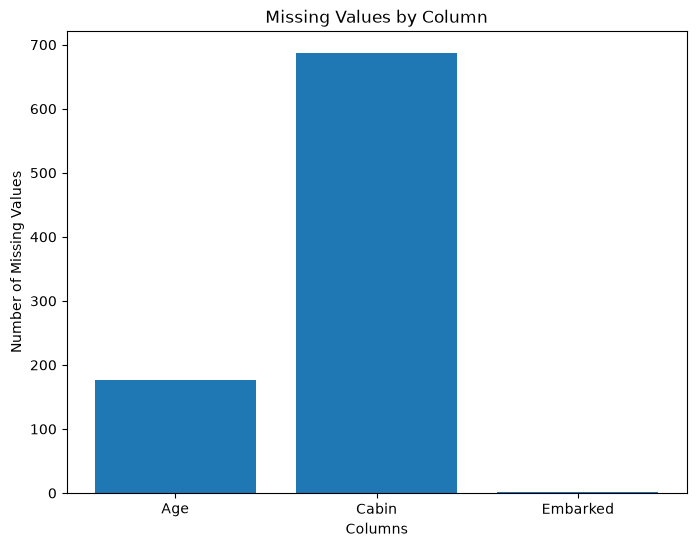

In [29]:
missing_table_nonzero = missing_table[missing_table["Missing Values"] > 0]
plt.figure(figsize=(8,6))
plt.bar(missing_table_nonzero.index,missing_table_nonzero["Missing Values"])
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
survival_counts=df["Survived"].value_counts()
print(f"Survived: :{survival_counts[1]} \nDid not survive:{survival_counts[0]}")

Survived: :342 
Did not survive:549


In [39]:
survival_percentage=df["Survived"].value_counts(normalize=True)*100
survival_percentage

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

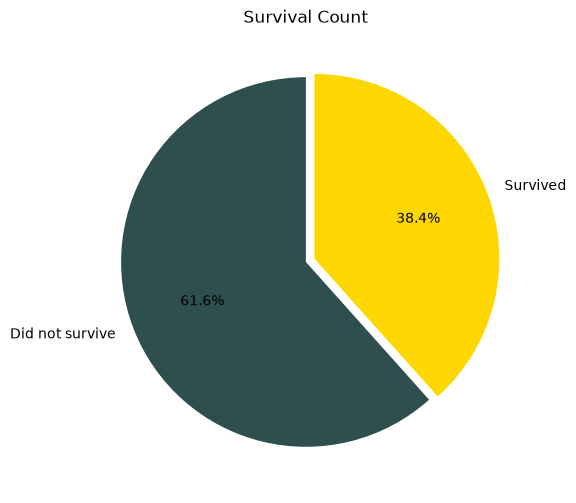

In [53]:
plt.figure(figsize=(8,6))
colors = ["darkslategray", "gold"]
labels = ["Did not survive", "Survived"]

plt.pie(
    survival_counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0,0.05]
)

plt.title("Survival Count")

plt.show()

In [55]:
df.groupby("Sex")["Survived"].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [62]:
# Survival rate by sex
survival_rate_by_sex = df.groupby("Sex")["Survived"].mean() * 100
survival_rate_by_sex

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

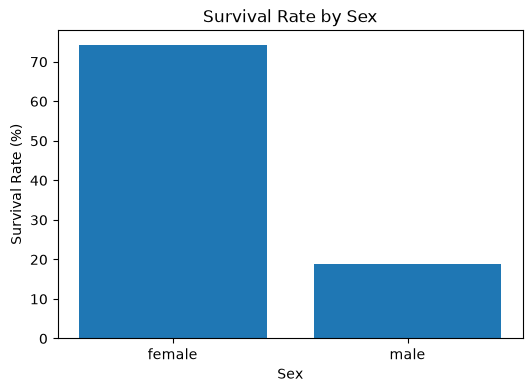

In [63]:
plt.figure(figsize=(6, 4))

plt.bar(survival_rate_by_sex.index, survival_rate_by_sex.values)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")

plt.show()

In [68]:
df.groupby("Pclass")["Survived"].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [72]:
survival_rate_by_Pclass =df.groupby("Pclass")["Survived"].mean()*100
survival_rate_by_Pclass

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

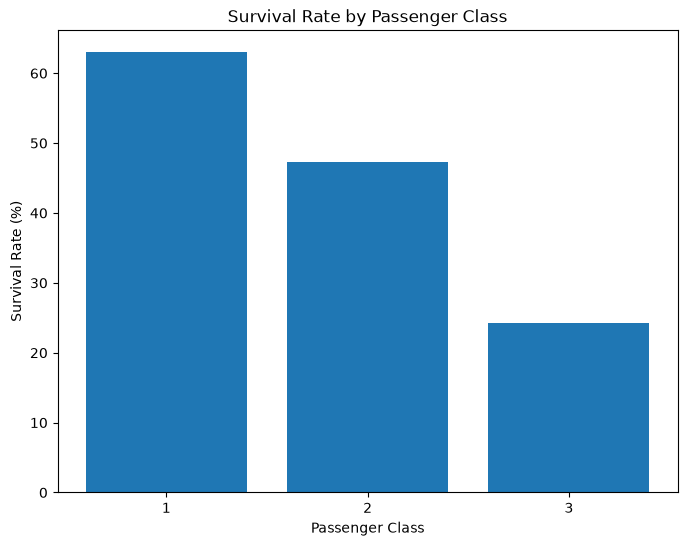

In [75]:
plt.figure(figsize=(8,6))
plt.bar(survival_rate_by_Pclass.index.astype(str),survival_rate_by_Pclass.values)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

 Age and Survival

In [77]:
df["Age"].isna().sum()

np.int64(177)

In [79]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

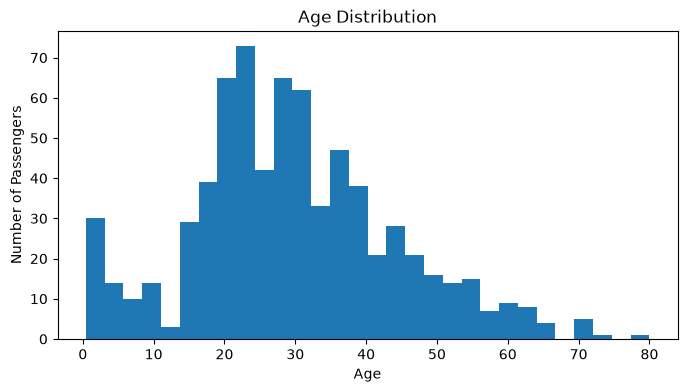

In [84]:
plt.figure(figsize=(8, 4))

plt.hist(df["Age"].dropna(), bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [95]:
survived_age=df[df["Survived"]==1]["Age"]
not_survived_age=df[df["Survived"]==0]["Age"]

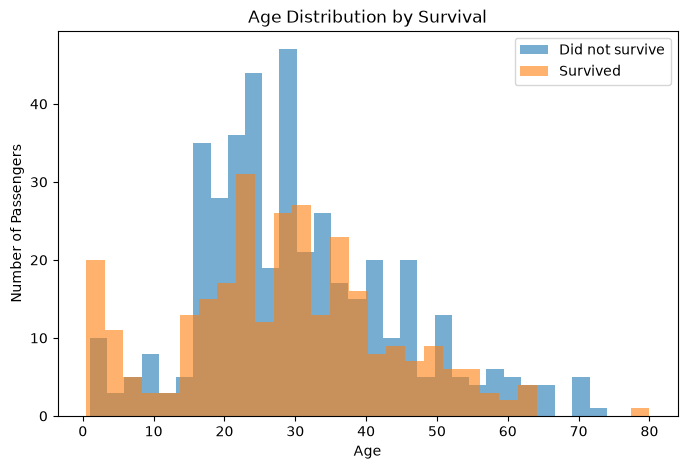

In [100]:
plt.figure(figsize=(8, 5))

plt.hist(not_survived_age, bins=30, alpha=0.6, label="Did not survive")
plt.hist(survived_age, bins=30, alpha=0.6, label="Survived")

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

In [101]:
df.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [102]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

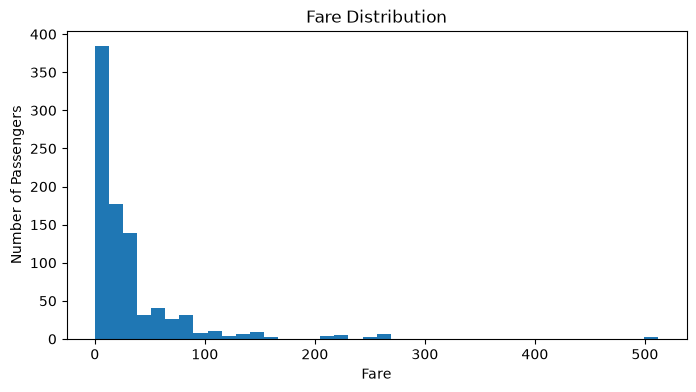

In [108]:
plt.figure(figsize=(8, 4))

plt.hist(df["Fare"], bins=40)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [109]:
survived_fare = df[df["Survived"] == 1]["Fare"]
not_survived_fare = df[df["Survived"] == 0]["Fare"]


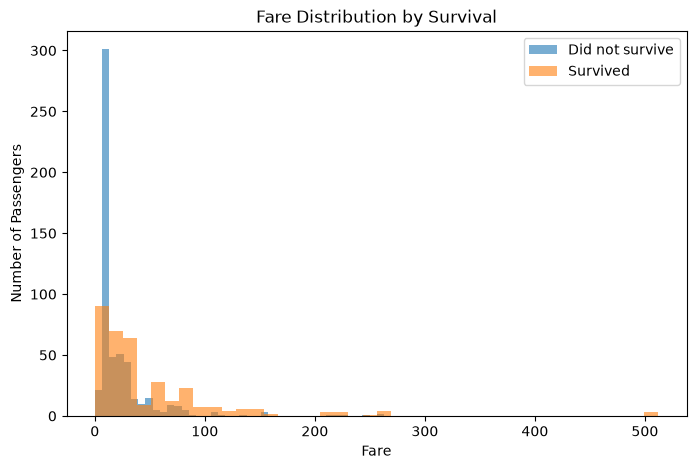

In [111]:
plt.figure(figsize=(8, 5))

plt.hist(not_survived_fare, bins=40, alpha=0.6, label="Did not survive")
plt.hist(survived_fare, bins=40, alpha=0.6, label="Survived")

plt.title("Fare Distribution by Survival")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

In [113]:

survival_by_class_sex = df.groupby(["Pclass", "Sex"])["Survived"].mean() * 100

survival_by_class_sex


Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64

## Data Cleaning

In this section, I will clean the dataset by checking missing values, duplicates, unnecessary columns, and creating useful new features for analysis.

In [117]:
df_clean=df.copy()
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [118]:
df_clean.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [119]:
df_clean = df_clean.drop("Cabin", axis=1)

In [120]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [122]:
age_median=df["Age"].median()
age_median

np.float64(28.0)

In [123]:
df_clean["Age"] = df_clean["Age"].fillna(age_median)

In [128]:
embarked_mode=df_clean["Embarked"].mode()[0]

In [130]:
df_clean["Embarked"]=df_clean["Embarked"].fillna(embarked_mode)

In [131]:
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [132]:
df_clean.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool>

In [133]:
df_clean.duplicated().sum()

np.int64(0)

In [134]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

In [135]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [139]:
df_clean["IsAlone"]=np.where(df_clean["FamilySize"]==1,"Alone","With Family")

In [140]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,With Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,With Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,With Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Alone


In [142]:
df_clean["AgeGroup"]=pd.cut(
    df_clean["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

In [143]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,With Family,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,With Family,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Alone,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,With Family,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Alone,Young Adult


In [144]:
df_clean.groupby("AgeGroup")["Survived"].mean() * 100

AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

In [145]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,With Family,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,With Family,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Alone,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,With Family,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Alone,Young Adult


In [148]:
age_group_survival=df_clean.groupby("AgeGroup")["Survived"].mean()*100
age_group_survival

AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

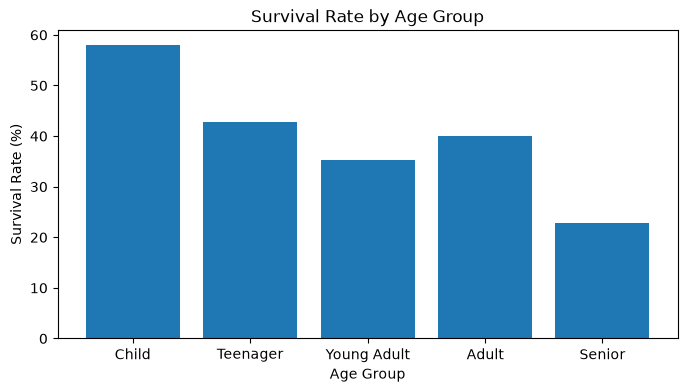

In [150]:
plt.figure(figsize=(8, 4))
plt.bar(age_group_survival.index.astype(str), age_group_survival.values)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

plt.show()

In [151]:
family_survival = df_clean.groupby("FamilySize")["Survived"].mean() * 100
family_survival

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

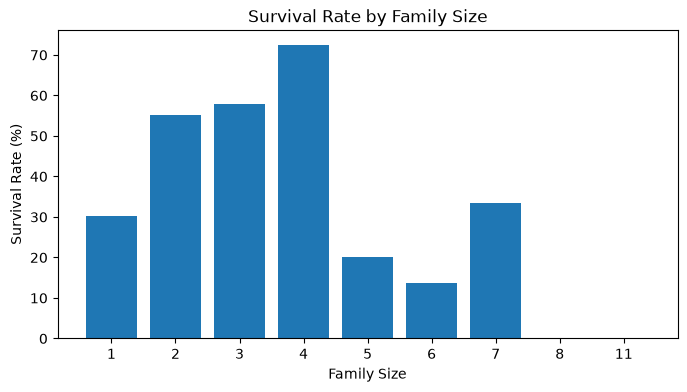

In [152]:
plt.figure(figsize=(8, 4))
plt.bar(family_survival.index.astype(str), family_survival.values)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

In [153]:
df_clean.to_csv("titanic_cleaned.csv", index=False)

In [154]:
import os
os.listdir()

['Titanic_EDA.ipynb',
 'titanic_cleaned.csv',
 'Titanic-Dataset.csv',
 '.ipynb_checkpoints',
 '.git']